# PFPA Summer Intern — Team 1
## Week 2: Automated Market Data Download (v3)

**Data sources — no rate limits:**
| Data | Source |
|------|--------|
| Stock price history + dividends | Yahoo Finance Chart API (direct HTTP, no library) |
| Balance sheet / financials | SEC EDGAR XBRL API (`data.sec.gov`) |
| Market cap, shares outstanding | SEC EDGAR (`dei:EntityCommonStockSharesOutstanding`) + Yahoo price |
| 1-Year Treasury (DGS1) + SOFR | FRED (Federal Reserve) |

**Output**: `./data/<TICKER>/` — CSV + Excel per company

---
## Step 0 · Install & Import

In [1]:
import subprocess, sys
pkgs = ['pandas', 'numpy', 'matplotlib', 'openpyxl', 'requests']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All packages installed')

✅ All packages installed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import os
import time
import warnings
from datetime import datetime, timedelta
from io import StringIO

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

plt.rcParams.update({
    'figure.figsize': (13, 4),
    'axes.grid':      True,
    'grid.alpha':     0.3,
    'font.size':      11,
})

print('✅ Imports complete')
print(f'   pandas version : {pd.__version__}')

✅ Imports complete
   pandas version : 2.1.4


---
## Step 1 · Configuration

In [3]:
# ══════════════════════════════════════════════════════════════════════
#  EDIT HERE — tickers and CIK mapping
# ══════════════════════════════════════════════════════════════════════

TICKERS = ['COST', 'KO', 'DELL', 'ORCL', 'PNC', 'WMT', 'INTU', 'AMZN', 'T', 'KHC']

# SEC EDGAR CIK numbers (stable; lookup: https://www.sec.gov/cgi-bin/browse-edgar?action=getcompany)
CIK_MAP = {
    'COST': '0000909832',
    'KO':   '0000021344',
    'DELL': '0001571996',
    'ORCL': '0001341439',
    'PNC':  '0000713676',
    'WMT':  '0000104169',
    'INTU': '0000896878',
    'AMZN': '0001018724',
    'T':    '0000732717',
    'KHC':  '0001637459',
}

HISTORY_YEARS = 2        # years of price history to download
N_ANNUAL      = 2        # number of annual 10-K filings to extract
OUTPUT_DIR    = './data'

# ══════════════════════════════════════════════════════════════════════

for t in TICKERS:
    os.makedirs(f'{OUTPUT_DIR}/{t}', exist_ok=True)

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
          '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

print(f'Tickers : {TICKERS}')
print(f'Output  : {os.path.abspath(OUTPUT_DIR)}')

Tickers : ['COST', 'KO', 'DELL', 'ORCL', 'PNC', 'WMT', 'INTU', 'AMZN', 'T', 'KHC']
Output  : C:\Users\wujie\OneDrive\Desktop\PFPA\w2\data


---
## Step 2 · Download Stock Price History (Yahoo Finance Chart API)

Uses the Yahoo Finance `/v8/finance/chart` endpoint directly via `requests`.  
No `yfinance` library → no rate-limit issues.

### Dividend Adjustment
- `Close` — split-adjusted close price (Yahoo `adjclose` ÷ adj_factor)
- `Dividends` — per-share dividend on ex-date
- `CumDividends` — cumulative dividends since period start
- `AdjClose_TR` = `Close` + `CumDividends` — total-return adjusted price (used as equity value $E_t$ in KMV)

In [4]:
YAHOO_HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Accept': 'application/json',
}

def download_price_yahoo(ticker: str, years: int = 2) -> pd.DataFrame:
    """
    Download daily OHLCV + dividends via Yahoo Finance Chart API (direct HTTP).
    Returns DataFrame with columns:
        Open, High, Low, Close, Volume, Dividends, Stock Splits,
        CumDividends, AdjClose_TR
    """
    range_str = f'{years}y'
    url = (f'https://query1.finance.yahoo.com/v8/finance/chart/{ticker}'
           f'?range={range_str}&interval=1d&events=history%7Cdiv%7Csplit')

    resp = requests.get(url, headers=YAHOO_HEADERS, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    result = data['chart']['result'][0]
    meta   = result['meta']
    ts     = result['timestamp']
    quote  = result['indicators']['quote'][0]
    adj    = result['indicators'].get('adjclose', [{}])[0].get('adjclose', [None]*len(ts))

    # Build price DataFrame
    df = pd.DataFrame({
        'Date'  : pd.to_datetime(ts, unit='s').tz_localize('UTC').tz_convert('America/New_York').tz_localize(None).normalize(),
        'Open'  : quote.get('open',   [None]*len(ts)),
        'High'  : quote.get('high',   [None]*len(ts)),
        'Low'   : quote.get('low',    [None]*len(ts)),
        'Close' : quote.get('close',  [None]*len(ts)),
        'Volume': quote.get('volume', [None]*len(ts)),
        'AdjClose_Raw': adj,
    }).set_index('Date')

    df = df.dropna(subset=['Close'])
    df[['Open','High','Low','Close']] = df[['Open','High','Low','Close']].round(4)

    # Parse dividend events
    div_events = result.get('events', {}).get('dividends', {})
    split_events = result.get('events', {}).get('splits', {})

    div_series = pd.Series(0.0, index=df.index)
    for ev in div_events.values():
        d = pd.Timestamp(ev['date'], unit='s').normalize()
        if d in div_series.index:
            div_series[d] += ev['amount']

    split_series = pd.Series(0.0, index=df.index)
    for ev in split_events.values():
        d = pd.Timestamp(ev['date'], unit='s').normalize()
        if d in split_series.index:
            split_series[d] = ev['splitRatio']

    df['Dividends']    = div_series
    df['Stock Splits'] = split_series

    # Dividend adjustment (total return)
    df['CumDividends'] = df['Dividends'].cumsum()
    df['AdjClose_TR']  = (df['Close'] + df['CumDividends']).round(4)

    df.index.name = 'Date'
    return df


# ── Download all tickers ──────────────────────────────────────────────────────
price_data = {}

print('Downloading price histories via Yahoo Chart API ...\n')
for t in TICKERS:
    print(f'  [{t}]', end=' ')
    try:
        df = download_price_yahoo(t, HISTORY_YEARS)
        price_data[t] = df
        df.to_csv(f'{OUTPUT_DIR}/{t}/{t}_price_history.csv')
        start, end = df.index[0].date(), df.index[-1].date()
        n_div = (df['Dividends'] > 0).sum()
        print(f'✅  {len(df)} days ({start} → {end})  '
              f'| Close: ${df["Close"].iloc[-1]:,.2f}  '
              f'| AdjClose_TR: ${df["AdjClose_TR"].iloc[-1]:,.2f}  '
              f'| Dividends: ${df["Dividends"].sum():.4f} ({n_div} events)')
    except Exception as e:
        print(f'❌  {e}')
    time.sleep(0.5)   # gentle pacing

print('\nAll price histories saved ✅')


  [COST] ✅  501 days (2024-06-26 → 2026-06-25)  | Close: $942.24  | AdjClose_TR: $952.39  | Dividends: $10.1500 (8 events)
  [KO] ✅  501 days (2024-06-26 → 2026-06-25)  | Close: $80.42  | AdjClose_TR: $84.49  | Dividends: $4.0700 (8 events)
  [DELL] ✅  501 days (2024-06-26 → 2026-06-25)  | Close: $409.45  | AdjClose_TR: $413.51  | Dividends: $4.0650 (8 events)
  [ORCL] ✅  501 days (2024-06-26 → 2026-06-25)  | Close: $152.46  | AdjClose_TR: $156.16  | Dividends: $3.7000 (8 events)
  [PNC] ✅  501 days (2024-06-26 → 2026-06-25)  | Close: $245.28  | AdjClose_TR: $258.48  | Dividends: $13.2000 (8 events)
  [WMT] ✅  501 days (2024-06-26 → 2026-06-25)  | Close: $115.78  | AdjClose_TR: $117.63  | Dividends: $1.8520 (8 events)
  [INTU] ✅  501 days (2024-06-26 → 2026-06-25)  | Close: $255.07  | AdjClose_TR: $263.73  | Dividends: $8.6600 (8 events)
  [AMZN] ✅  501 days (2024-06-26 → 2026-06-25)  | Close: $227.01  | AdjClose_TR: $227.01  | Dividends: $0.0000 (0 events)
  [T] ✅  501 days (2024-06-

### 2.1 · Preview Price Data

In [5]:
for t, df in price_data.items():
    print(f'\n── {t} — last 5 trading days ────────────────────────────')
    display(df[['Open','High','Low','Close','Volume','Dividends','CumDividends','AdjClose_TR']].tail(5))


── COST — last 5 trading days ────────────────────────────


,Open,High,Low,Close,Volume,Dividends,CumDividends,AdjClose_TR
Date,,,,,,,,
2026-06-18,962.70,964.00,948.31,951.45,3742900,0.00,10.15,961.60
2026-06-22,948.57,956.23,942.53,951.35,2191900,0.00,10.15,961.50
2026-06-23,964.50,966.38,953.49,957.68,2529800,0.00,10.15,967.83
2026-06-24,962.03,967.94,957.00,961.09,2020200,0.00,10.15,971.24
2026-06-25,949.57,955.75,938.63,942.24,2421575,0.00,10.15,952.39



── KO — last 5 trading days ────────────────────────────


,Open,High,Low,Close,Volume,Dividends,CumDividends,AdjClose_TR
Date,,,,,,,,
2026-06-18,79.87,80.01,78.74,79.39,46857900,0.00,4.07,83.46
2026-06-22,79.25,80.06,79.06,79.53,21205900,0.00,4.07,83.60
2026-06-23,81.33,81.33,79.83,80.31,16854000,0.00,4.07,84.38
2026-06-24,80.89,81.58,80.56,80.60,20632600,0.00,4.07,84.67
2026-06-25,80.53,81.38,79.97,80.42,16008229,0.00,4.07,84.49



── DELL — last 5 trading days ────────────────────────────


...

,Open,High,Low,Close,Volume,Dividends,CumDividends,AdjClose_TR
Date,,,,,,,,
2026-06-18,240.12,245.73,236.02,244.39,75624400,0.00,0.00,244.39
2026-06-22,240.08,242.00,232.24,232.79,68388500,0.00,0.00,232.79
2026-06-23,232.55,236.87,232.00,234.11,60492600,0.00,0.00,234.11
2026-06-24,233.85,242.42,232.95,234.27,70282600,0.00,0.00,234.27
2026-06-25,231.93,232.32,225.56,227.01,76001063,0.00,0.00,227.01



── T — last 5 trading days ────────────────────────────


,Open,High,Low,Close,Volume,Dividends,CumDividends,AdjClose_TR
Date,,,,,,,,
2026-06-18,22.46,22.52,21.99,22.01,94242900,0.00,2.22,24.23
2026-06-22,22.03,22.47,22.01,22.10,68522300,0.00,2.22,24.32
2026-06-23,22.31,22.98,22.19,22.81,73551900,0.00,2.22,25.03
2026-06-24,22.84,22.94,22.31,22.37,57297300,0.00,2.22,24.59
2026-06-25,22.25,22.63,22.23,22.42,33794979,0.00,2.22,24.64



── KHC — last 5 trading days ────────────────────────────


,Open,High,Low,Close,Volume,Dividends,CumDividends,AdjClose_TR
Date,,,,,,,,
2026-06-18,23.09,23.14,22.75,22.82,21350600,0.00,3.20,26.02
2026-06-22,22.65,22.72,22.00,22.03,16782200,0.00,3.20,25.23
2026-06-23,22.36,22.60,22.23,22.47,12665500,0.00,3.20,25.67
2026-06-24,22.55,23.07,22.55,22.94,16336000,0.00,3.20,26.14
2026-06-25,22.99,23.84,22.94,23.47,15065486,0.00,3.20,26.67


### 2.2 · Plot: Close vs Total Return Adjusted Price

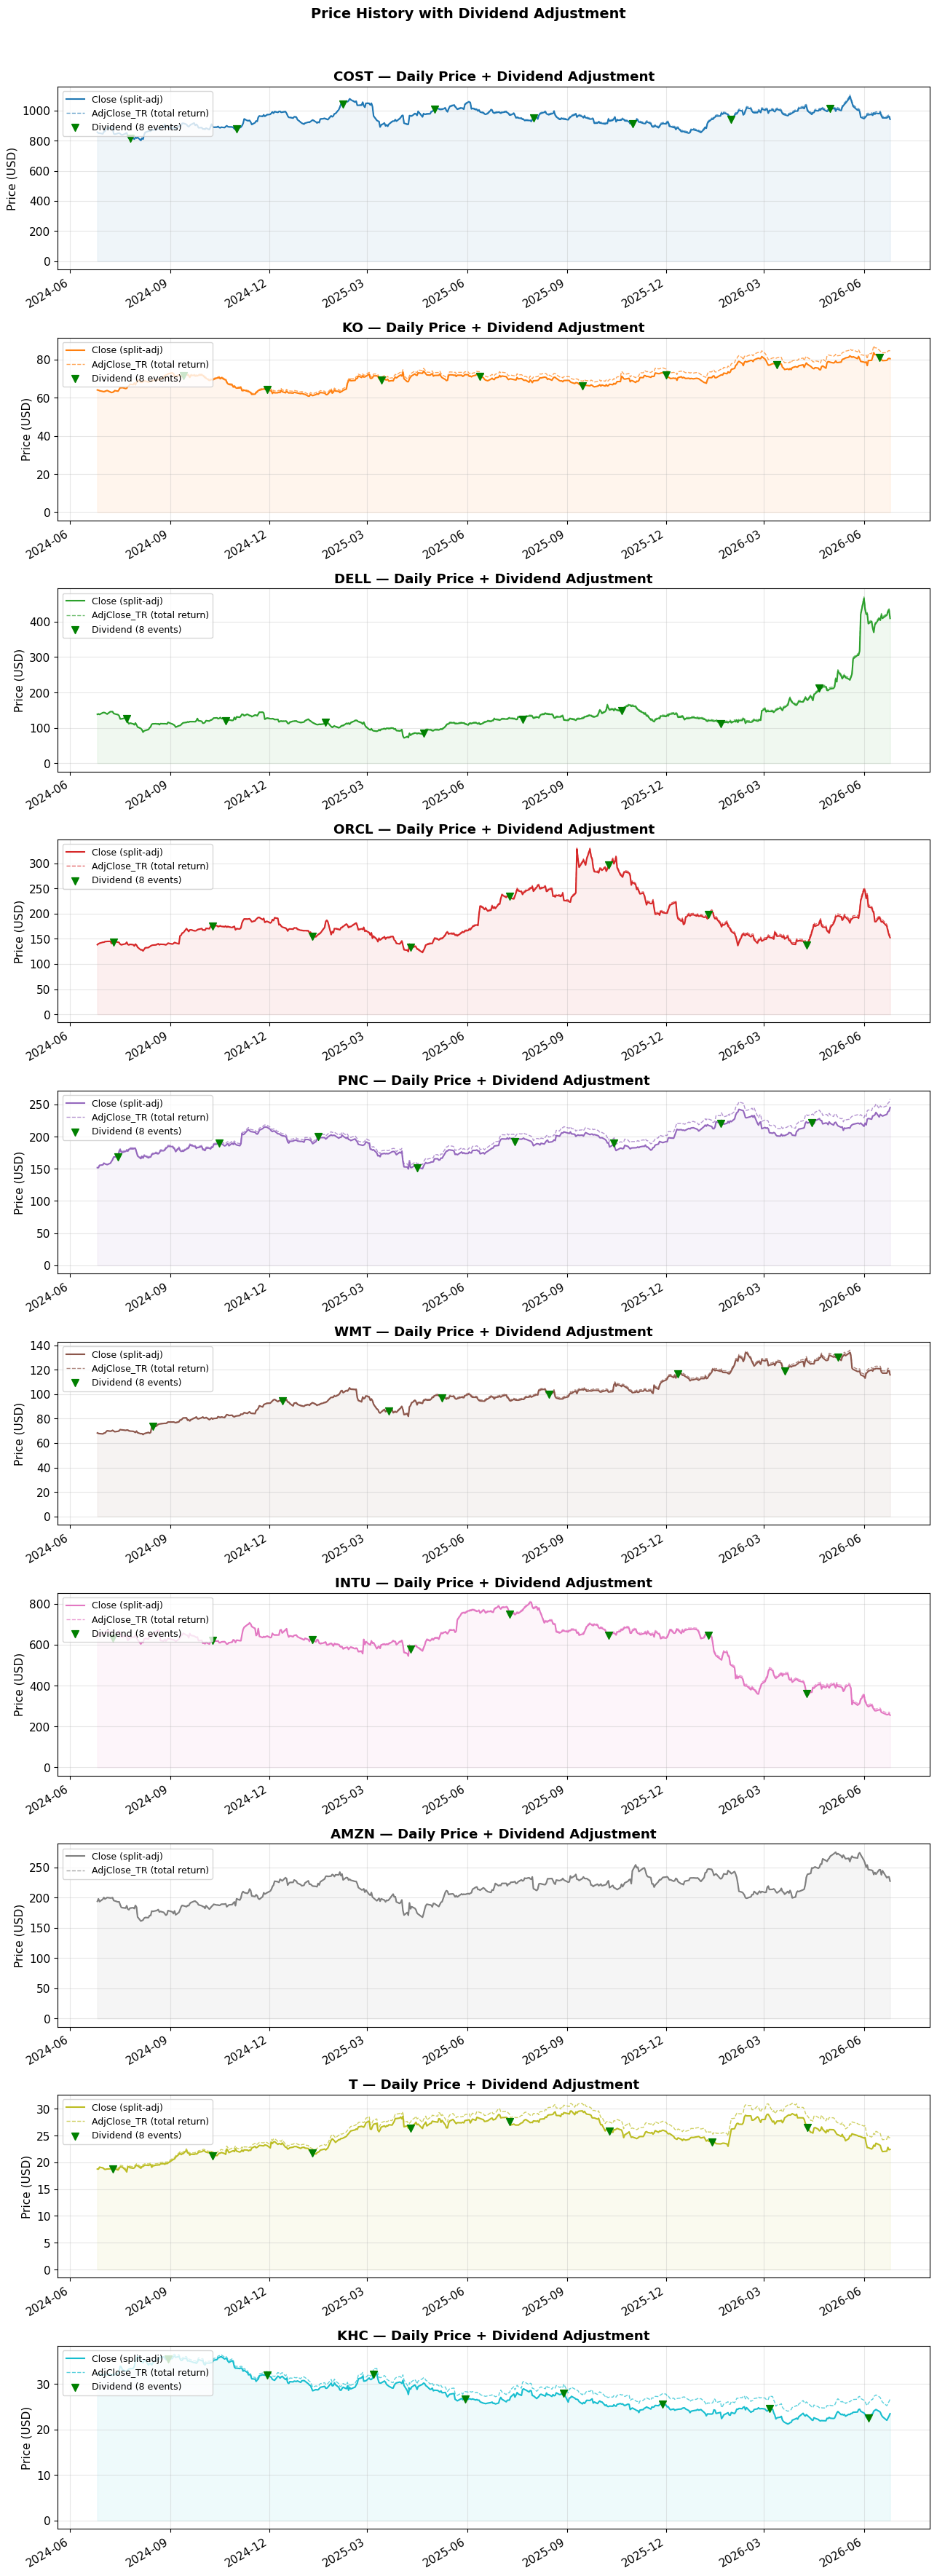

Chart saved ✅


In [6]:
fig, axes = plt.subplots(len(price_data), 1,
                         figsize=(13, 3.5 * len(price_data)), sharex=False)
if len(price_data) == 1: axes = [axes]

for ax, (t, df), color in zip(axes, price_data.items(), COLORS):
    ax.plot(df.index, df['Close'],       color=color, lw=1.5, label='Close (split-adj)')
    ax.plot(df.index, df['AdjClose_TR'], color=color, lw=1.0,
            linestyle='--', alpha=0.7, label='AdjClose_TR (total return)')
    ax.fill_between(df.index, df['Close'], alpha=0.07, color=color)
    div_dates = df[df['Dividends'] > 0]
    if not div_dates.empty:
        ax.scatter(div_dates.index, div_dates['Close'],
                   marker='v', color='green', s=50, zorder=5,
                   label=f'Dividend ({len(div_dates)} events)')
    ax.set_title(f'{t} — Daily Price + Dividend Adjustment', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Price History with Dividend Adjustment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/price_history_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✅')

### 2.3 · Plot: Normalised Total Return Performance

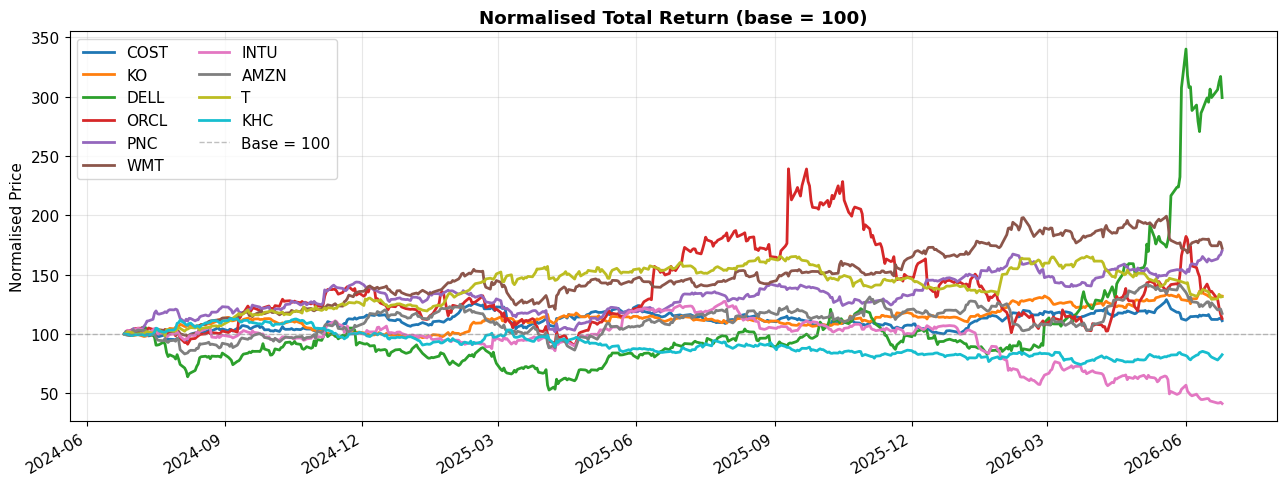

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
for (t, df), color in zip(price_data.items(), COLORS):
    tr = df['AdjClose_TR'].dropna()
    ax.plot(tr.index, tr / tr.iloc[0] * 100, label=t, color=color, lw=2)
ax.axhline(100, color='gray', linestyle='--', lw=1, alpha=0.5, label='Base = 100')
ax.set_title('Normalised Total Return (base = 100)', fontweight='bold')
ax.set_ylabel('Normalised Price')
ax.legend(ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/normalised_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3 · Download Financials & Shares from SEC EDGAR XBRL API

**Endpoint**: `https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json`  
Returns every XBRL-tagged fact ever filed by the company (10-K, 10-Q, 8-K…).

### GAAP tag priority lists
For each field, we try tags in order and take the first non-null annual (10-K FY) value.

In [8]:
SEC_HEADERS = {'User-Agent': 'PFPA-Team1 research@columbia.edu'}

# ── GAAP tag candidate lists (priority order) ─────────────────────────────────
FIELD_DEFS = {
    'totalDebt': [
        'DebtLongtermAndShorttermCombinedAmount',
        'LongTermDebtAndFinanceLeaseObligationsCurrentAndNoncurrent',
        'LongTermDebtAndCapitalLeaseObligationsIncludingCurrentMaturities',
        'DebtAndCapitalLeaseObligations',
        'LongTermDebt',
    ],
    'totalLiabilities': ['Liabilities'],
    'currentDebt': [
        'DebtCurrent',
        'ShortTermBorrowings',
        'ShortTermDebt',
        'LongTermDebtCurrent',
        'LongTermDebtAndCapitalLeaseObligationsCurrent',
    ],
    'currentLiabilities': ['LiabilitiesCurrent'],
    'longTermDebt': [
        'LongTermDebtNoncurrent',
        'LongTermDebt',
        'LongTermDebtAndCapitalLeaseObligations',
        'LongTermDebtAndFinanceLeaseObligationsNoncurrent',
        'LongTermNotesPayable',  
        'SeniorNotes',
    ],
    'longTermLiabilities': ['LiabilitiesNoncurrent'],
    'dividendCash': [
        'DividendsCommonStockCash',
        'PaymentsOfDividendsCommonStock',
        'PaymentsOfDividends',
        'DividendsCash',
        'DividendsCommonStock',
        'Dividends',
    ],
    'dividendPerShare': [
        'CommonStockDividendsPerShareDeclared',
        'CommonStockDividendsPerShareCashPaid',
    ],
    'totalAssets'       : ['Assets'],
    'stockholdersEquity': [
        'StockholdersEquity',
        'StockholdersEquityAttributableToParent',
        'CommonStockEquity',
        'StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest',  
        'PartnersCapitalIncludingPortionAttributableToNoncontrollingInterest',
    ],
    'cashAndEquivalents': [
        'CashAndCashEquivalentsAtCarryingValue',
        'CashCashEquivalentsAndShortTermInvestments',
        'CashAndCashEquivalents',
    ],
}

SHARES_TAGS = ['EntityCommonStockSharesOutstanding']


def fetch_sec_facts(cik: str) -> dict:
    """Fetch all XBRL company facts from SEC EDGAR."""
    url  = f'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json'
    resp = requests.get(url, headers=SEC_HEADERS, timeout=60)
    resp.raise_for_status()
    return resp.json()


def get_fact_units(facts: dict, tag: str) -> list:
    """Return all fact observations for a given GAAP tag."""
    item = facts.get('us-gaap', {}).get(tag) or facts.get('dei', {}).get(tag)
    if not item or not item.get('units'):
        return []
    for unit in ['USD', 'shares', 'USD/shares', 'pure']:
        if unit in item['units']:
            return [{**x, 'unit': unit} for x in item['units'][unit]]
    first = next(iter(item['units']))
    return [{**x, 'unit': first} for x in item['units'][first]]


def get_annual_facts(facts: dict, tag: str) -> list:
    """Return 10-K annual facts for a tag, sorted newest first."""
    return sorted(
        [x for x in get_fact_units(facts, tag)
         if x.get('form', '').startswith('10-K')
         and x.get('fy')
         and (not x.get('fp') or x['fp'] == 'FY')
         and x.get('val') is not None],
        key=lambda x: (-(x.get('fy') or 0), -(x.get('filed') or '').__len__())
    )


def pick_annual(facts: dict, candidates: list, fy: int):
    """Try each candidate tag and return first non-null annual value for given FY."""
    for tag in candidates:
        rows = [x for x in get_annual_facts(facts, tag) if x.get('fy') == fy]
        if rows:
            rows.sort(key=lambda x: x.get('filed', ''), reverse=True)
            f = rows[0]
            return {'val': f['val'], 'tag': tag, 'end': f.get('end'),
                    'fy': f.get('fy'), 'filed': f.get('filed'), 'unit': f.get('unit')}
    return None


def get_annual_fiscal_years(facts: dict, n: int = 2) -> list:
    """Get the N most recent fiscal years with 10-K data."""
    years = set()
    for tag in ['Liabilities', 'Assets', 'LongTermDebt', 'LiabilitiesCurrent']:
        for x in get_annual_facts(facts, tag):
            if x.get('fy'):
                years.add(x['fy'])
    return sorted(years, reverse=True)[:n]


def get_latest_shares(facts: dict):
    """Get most recent shares outstanding from any filing."""
    for tag in SHARES_TAGS:
        rows = [x for x in get_fact_units(facts, tag) if x.get('val') is not None]
        if rows:
            rows.sort(key=lambda x: (x.get('end', ''), x.get('filed', '')), reverse=True)
            f = rows[0]
            return {'val': f['val'], 'end': f.get('end'), 'filed': f.get('filed'),
                    'form': f.get('form'), 'tag': tag}
    return None


print('SEC EDGAR helper functions defined ✅')

SEC EDGAR helper functions defined ✅


In [9]:
# ── Download SEC data for all tickers ────────────────────────────────────────
sec_facts   = {}    # raw facts JSON per ticker
sec_financials = {} # extracted annual financials per ticker
company_info   = {} # shares, market cap, entity name

print('Downloading SEC EDGAR company facts ...\n')

for t in TICKERS:
    cik = CIK_MAP[t]
    print(f'  [{t} | CIK {cik}]', end=' ')
    try:
        facts_json = fetch_sec_facts(cik)
        sec_facts[t] = facts_json
        entity_name = facts_json.get('entityName', t)

        # ── Shares outstanding ────────────────────────────────────────────
        shares_fact = get_latest_shares(facts_json['facts'])
        shares = float(shares_fact['val']) if shares_fact else np.nan

        # ── Latest price from price_data ──────────────────────────────────
        latest_close = price_data[t]['Close'].iloc[-1] if t in price_data else np.nan
        market_cap   = shares * latest_close if not np.isnan(shares) else np.nan

        company_info[t] = {
            'longName'  : entity_name,
            'cik'       : cik,
            'shares'    : shares,
            'marketCap' : market_cap,
            'latestClose': latest_close,
            'sharesEnd'  : shares_fact['end'] if shares_fact else None,
            'sharesFiled': shares_fact['filed'] if shares_fact else None,
            'sharesForm' : shares_fact['form'] if shares_fact else None,
        }

        # ── Extract annual financials for N_ANNUAL fiscal years ───────────
        fys = get_annual_fiscal_years(facts_json['facts'], N_ANNUAL)
        rows = []
        for fy in sorted(fys):
            row = {'ticker': t, 'company': entity_name, 'cik': cik, 'fiscalYear': fy}
            for field, candidates in FIELD_DEFS.items():
                f = pick_annual(facts_json['facts'], candidates, fy)
                if field == 'dividendPerShare':
                    row[field] = abs(float(f['val'])) if f else np.nan
                else:
                    row[field] = abs(float(f['val'])) / 1e6 if f else np.nan  # $mm
                row[f'{field}_tag'] = f['tag'] if f else ''

            # Compute longTermLiabilities if missing (Total - Current)
            if np.isnan(row.get('longTermLiabilities', np.nan)):
                tl = row.get('totalLiabilities', np.nan)
                cl = row.get('currentLiabilities', np.nan)
                if not np.isnan(tl) and not np.isnan(cl):
                    row['longTermLiabilities'] = tl - cl
                    row['longTermLiabilities_tag'] = 'Computed: Liabilities - LiabilitiesCurrent'


            if np.isnan(row.get('totalLiabilities', np.nan)):
                ta = row.get('totalAssets', np.nan)
                eq = row.get('stockholdersEquity', np.nan)
                if not np.isnan(ta) and not np.isnan(eq):
                    row['totalLiabilities'] = ta - eq
                    row['totalLiabilities_tag'] = 'Computed: Assets - StockholdersEquity'

            # KMV Debt D = currentDebt + 0.5 × longTermDebt
            st = row.get('currentDebt', np.nan)
            lt = row.get('longTermDebt', np.nan)
            st_s = st if not np.isnan(st) else 0.0
            lt_s = lt if not np.isnan(lt) else 0.0
            row['KMV_Debt_D'] = st_s + 0.5 * lt_s

            # Net Debt = totalDebt - cash
            td   = row.get('totalDebt', np.nan)
            cash = row.get('cashAndEquivalents', np.nan)
            row['netDebt'] = (td - cash) if not np.isnan(td) and not np.isnan(cash) else np.nan

            rows.append(row)

        df_fin = pd.DataFrame(rows)
        sec_financials[t] = df_fin
        df_fin.to_csv(f'{OUTPUT_DIR}/{t}/{t}_financials.csv', index=False)

        fy_str = ', '.join(str(r['fiscalYear']) for r in rows)
        print(f'✅  {entity_name}  | FY: {fy_str}  '
              f'| Shares: {shares/1e6:,.1f}M  | MarketCap: ${market_cap/1e9:.1f}B')
    except Exception as e:
        print(f'❌  {e}')
    time.sleep(0.5)  # SEC requests: be polite

print('\nSEC data downloaded and saved ✅')


  [COST | CIK 0000909832] ✅  COSTCO WHOLESALE CORP /NEW  | FY: 2024, 2025  | Shares: 443.5M  | MarketCap: $417.9B
  [KO | CIK 0000021344] ✅  COCA COLA CO  | FY: 2024, 2025  | Shares: 4,302.5M  | MarketCap: $346.0B
  [DELL | CIK 0001571996] ✅  Dell Technologies Inc.  | FY: 2025, 2026  | Shares: nanM  | MarketCap: $nanB
  [ORCL | CIK 0001341439] ✅  Oracle Corporation  | FY: 2025, 2026  | Shares: 2,880.5M  | MarketCap: $439.2B
  [PNC | CIK 0000713676] ✅  PNC FINANCIAL SERVICES GROUP, INC.  | FY: 2024, 2025  | Shares: 401.6M  | MarketCap: $98.5B
  [WMT | CIK 0000104169] ✅  WALMART INC.  | FY: 2025, 2026  | Shares: 7,958.1M  | MarketCap: $921.4B
  [INTU | CIK 0000896878] ✅  INTUIT INC.  | FY: 2024, 2025  | Shares: 273.5M  | MarketCap: $69.8B
  [AMZN | CIK 0001018724] ✅  AMAZON COM INC  | FY: 2024, 2025  | Shares: 10,757.1M  | MarketCap: $2442.0B
  [T | CIK 0000732717] ✅  AT&T INC.  | FY: 2024, 2025  | Shares: 6,948.3M  | MarketCap: $155.8B
  [KHC | CIK 0001637459] ✅  Kraft Heinz Co  | FY: 

In [10]:
# ── DELL Special Case: MarketCap ──────────────────────────────────────────
# DELL Class C + Class D shares (from latest 10-Q, 2026-05-01)
# Source: https://www.sec.gov/cgi-bin/browse-edgar?action=getcompany&CIK=0001571996

if 'DELL' in company_info and np.isnan(company_info['DELL']['shares']):
    print('Fixing DELL shares outstanding (multi-class stock) ...')

    dell_facts = sec_facts['DELL']['facts']
    share_rows = []
    for x in get_fact_units(dell_facts, 'EntityCommonStockSharesOutstanding'):
        if x.get('val') is not None and x.get('end'):
            share_rows.append(x)

    if share_rows:
        # Group by filing date, sum all share classes filed together
        from collections import defaultdict
        by_filing = defaultdict(float)
        by_filing_end = {}
        for x in share_rows:
            key = (x.get('filed', ''), x.get('end', ''))
            by_filing[key] += float(x['val'])
            by_filing_end[key] = x.get('end')

        # Take the most recent filing
        latest_key = sorted(by_filing.keys(), reverse=True)[0]
        total_shares = by_filing[latest_key]
        latest_end   = by_filing_end[latest_key]

        company_info['DELL']['shares']    = total_shares
        company_info['DELL']['sharesEnd'] = latest_end
        latest_close = company_info['DELL']['latestClose']
        company_info['DELL']['marketCap'] = total_shares * latest_close

        print(f'  DELL shares (all classes summed): {total_shares/1e6:,.1f}M')
        print(f'  DELL MarketCap: ${total_shares * latest_close / 1e9:.2f}B')
    else:
        # Hardcode from latest 10-Q (2026-06-09 filing, period 2026-05-01)
        # Class C: 666,422,882 + Class D: 181,748,407 = 848,171,289
        DELL_SHARES = 848_171_289
        company_info['DELL']['shares']    = DELL_SHARES
        company_info['DELL']['sharesEnd'] = '2026-05-01'
        latest_close = company_info['DELL']['latestClose']
        company_info['DELL']['marketCap'] = DELL_SHARES * latest_close
        print(f'  DELL shares (hardcoded from 10-Q): {DELL_SHARES/1e6:,.1f}M')
        print(f'  DELL MarketCap: ${DELL_SHARES * latest_close / 1e9:.2f}B')



Fixing DELL shares outstanding (multi-class stock) ...
  DELL shares (hardcoded from 10-Q): 848.2M
  DELL MarketCap: $347.28B


In [11]:
print("Scanning for missing totalLiabilities ...\n")

for t, df_fin in sec_financials.items():
    for idx, row in df_fin.iterrows():
        if pd.isna(row.get('totalLiabilities')):
            ta = row.get('totalAssets', np.nan)
            eq = row.get('stockholdersEquity', np.nan)
            if not np.isnan(ta) and not np.isnan(eq):
                val = ta - eq
                sec_financials[t].at[idx, 'totalLiabilities'] = val
                fy = int(row['fiscalYear'])
                print(f"  [{t}] FY{fy}: {ta:,.0f} - {eq:,.0f} = {val:,.0f} $mm  ✅")
            else:
                fy = int(row['fiscalYear'])
                print(f"  [{t}] FY{fy}: ⚠️  totalAssets={row.get('totalAssets')}  equity={row.get('stockholdersEquity')} — cannot compute")


for t, df_fin in sec_financials.items():
    df_fin.to_csv(f'{OUTPUT_DIR}/{t}/{t}_financials.csv', index=False)

print("\nAll patched CSVs saved ✅")

Scanning for missing totalLiabilities ...


All patched CSVs saved ✅


### 3.1 · Company Overview

In [12]:
print('\n' + '='*75)
print('  COMPANY OVERVIEW')
print('='*75)
for t, info in company_info.items():
    div_row = sec_financials[t].iloc[-1] if t in sec_financials and not sec_financials[t].empty else {}
    dps  = div_row.get('dividendPerShare', np.nan) if isinstance(div_row, dict) else div_row.get('dividendPerShare', np.nan)
    dcash= div_row.get('dividendCash', np.nan)     if isinstance(div_row, dict) else div_row.get('dividendCash', np.nan)
    print(f"""
  ── {t} ─────────────────────────────────────────────────────
  Full Name          : {info.get('longName')}
  CIK                : {info.get('cik')}
  Shares Outstanding : {info.get('shares', np.nan)/1e6:>14,.1f}M  (as of {info.get('sharesEnd')})
  Latest Close       : ${info.get('latestClose', np.nan):>14,.2f}
  Market Cap         : ${info.get('marketCap', np.nan)/1e9:>14,.2f}B
  Dividend/Share(FY) : ${dps:>14,.4f}
  Dividend Cash ($mm): ${dcash:>14,.1f}
""")


  COMPANY OVERVIEW

  ── COST ─────────────────────────────────────────────────────
  Full Name          : COSTCO WHOLESALE CORP /NEW
  CIK                : 0000909832
  Shares Outstanding :          443.5M  (as of 2026-05-27)
  Latest Close       : $        942.24
  Market Cap         : $        417.86B
  Dividend/Share(FY) : $       19.3600
  Dividend Cash ($mm): $       8,589.0


  ── KO ─────────────────────────────────────────────────────
  Full Name          : COCA COLA CO
  CIK                : 0000021344
  Shares Outstanding :        4,302.5M  (as of 2026-04-28)
  Latest Close       : $         80.42
  Market Cap         : $        346.01B
  Dividend/Share(FY) : $        1.8400
  Dividend Cash ($mm): $       7,952.0


  ── DELL ─────────────────────────────────────────────────────
  Full Name          : Dell Technologies Inc.
  CIK                : 0001571996
  Shares Outstanding :          848.2M  (as of 2026-05-01)
  Latest Close       : $        409.45
  Market Cap         

### 3.2 · Preview Annual Financials

In [13]:
show_cols = [
    'fiscalYear',
    'currentDebt', 'currentLiabilities',
    'longTermDebt', 'longTermLiabilities',
    'totalDebt', 'totalLiabilities',
    'KMV_Debt_D', 'netDebt',
    'totalAssets', 'stockholdersEquity',
    'dividendPerShare', 'dividendCash',
]

for t, df_fin in sec_financials.items():
    print(f'\n── {t} — Annual Financials ($mm unless noted) ──────────────────')
    avail = [c for c in show_cols if c in df_fin.columns]
    display(df_fin[avail].to_string(index=False))
    print()


── COST — Annual Financials ($mm unless noted) ──────────────────


' fiscalYear  currentDebt  currentLiabilities  longTermDebt  longTermLiabilities  totalDebt  totalLiabilities  KMV_Debt_D  netDebt  totalAssets  stockholdersEquity  dividendPerShare  dividendCash\n       2024     1,081.00           33,583.00      5,377.00            10,353.00        NaN         43,936.00    3,769.50      NaN    64,166.00           25,058.00              3.84      1,703.00\n       2025       103.00           35,464.00      5,794.00            10,745.00        NaN         46,209.00    3,000.00      NaN    68,994.00           23,622.00             19.36      8,589.00'



── KO — Annual Financials ($mm unless noted) ──────────────────


' fiscalYear  currentDebt  currentLiabilities  longTermDebt  longTermLiabilities  totalDebt  totalLiabilities  KMV_Debt_D   netDebt  totalAssets  stockholdersEquity  dividendPerShare  dividendCash\n       2024     1,960.00           23,571.00     35,547.00                  NaN  37,507.00         71,762.00   19,733.50 27,988.00    97,703.00           25,941.00              1.76      7,616.00\n       2025       648.00           25,249.00     42,375.00                  NaN  43,023.00         75,693.00   21,835.50 33,657.00   100,549.00           24,856.00              1.84      7,952.00'



── DELL — Annual Financials ($mm unless noted) ──────────────────


...

' fiscalYear  currentDebt  currentLiabilities  longTermDebt  longTermLiabilities  totalDebt  totalLiabilities  KMV_Debt_D    netDebt  totalAssets  stockholdersEquity  dividendPerShare  dividendCash\n       2024       147.00          164,917.00     58,314.00                  NaN  67,182.00        324,430.00   29,304.00  -6,205.00   462,675.00          138,245.00               NaN           NaN\n       2025       151.00          179,431.00     52,623.00                  NaN  58,000.00        381,811.00   26,462.50 -20,779.00   527,854.00          146,043.00               NaN           NaN'



── T — Annual Financials ($mm unless noted) ──────────────────


' fiscalYear  currentDebt  currentLiabilities  longTermDebt  longTermLiabilities  totalDebt  totalLiabilities  KMV_Debt_D    netDebt  totalAssets  stockholdersEquity  dividendPerShare  dividendCash\n       2024     9,477.00           51,127.00    133,402.00                  NaN 135,240.00        223,205.00   76,178.00 116,017.00   407,060.00          183,855.00              1.11      9,859.00\n       2025     5,089.00           46,872.00    122,116.00                  NaN 123,532.00        288,338.00   66,147.00 119,831.00   394,795.00          106,457.00              1.11      8,136.00'



── KHC — Annual Financials ($mm unless noted) ──────────────────


' fiscalYear  currentDebt  currentLiabilities  longTermDebt  longTermLiabilities  totalDebt  totalLiabilities  KMV_Debt_D   netDebt  totalAssets  stockholdersEquity  dividendPerShare  dividendCash\n       2024       638.00            8,037.00     19,394.00            32,580.00  20,032.00         40,617.00   10,335.00 18,632.00    90,339.00           49,526.00              1.60      1,960.00\n       2025       654.00            7,253.00     19,215.00            31,709.00  19,869.00         38,962.00   10,261.50 18,535.00    88,287.00           49,185.00              1.60      1,965.00'

---
## Step 4 · Daily Market Cap

$$E_t = \text{AdjClose\_TR}(t) \times \text{Shares Outstanding}$$

`AdjClose_TR` (total-return price) is used so the equity value reflects dividend distributions.

In [14]:
market_cap_data = {}

print('Computing daily market cap ...\n')
for t in TICKERS:
    if t not in price_data or t not in company_info:
        print(f'  [{t}] ⚠️  Missing price or company info')
        continue
    shares = company_info[t]['shares']
    if np.isnan(shares):
        print(f'  [{t}] ⚠️  Shares outstanding not available')
        continue

    df = price_data[t][['Close','AdjClose_TR','Dividends','CumDividends']].copy()
    df['Shares']          = shares
    df['MarketCap_Close'] = df['Close']       * shares
    df['MarketCap_TR']    = df['AdjClose_TR'] * shares   # KMV equity E_t

    market_cap_data[t] = df
    df.to_csv(f'{OUTPUT_DIR}/{t}/{t}_market_cap.csv')

    mc = df['MarketCap_TR'].iloc[-1]
    print(f'  [{t}] ✅  Latest MarketCap_TR: ${mc/1e9:.2f}B  | Shares: {shares/1e6:,.1f}M')

print('\nMarket cap data saved ✅')

# Recompute market cap for DELL
if 'DELL' in company_info and 'DELL' not in market_cap_data:
    shares = company_info['DELL']['shares']
    if not np.isnan(shares):
        df = price_data['DELL'][['Close','AdjClose_TR','Dividends','CumDividends']].copy()
        df['Shares']          = shares
        df['MarketCap_Close'] = df['Close']       * shares
        df['MarketCap_TR']    = df['AdjClose_TR'] * shares
        market_cap_data['DELL'] = df
        df.to_csv(f'{OUTPUT_DIR}/DELL/DELL_market_cap.csv')
        print(f'  [DELL] ✅  MarketCap_TR (latest): ${df["MarketCap_TR"].iloc[-1]/1e9:.2f}B')

Computing daily market cap ...

  [COST] ✅  Latest MarketCap_TR: $422.36B  | Shares: 443.5M
  [KO] ✅  Latest MarketCap_TR: $363.52B  | Shares: 4,302.5M
  [DELL] ✅  Latest MarketCap_TR: $350.73B  | Shares: 848.2M
  [ORCL] ✅  Latest MarketCap_TR: $449.81B  | Shares: 2,880.5M
  [PNC] ✅  Latest MarketCap_TR: $103.80B  | Shares: 401.6M
  [WMT] ✅  Latest MarketCap_TR: $936.12B  | Shares: 7,958.1M
  [INTU] ✅  Latest MarketCap_TR: $72.14B  | Shares: 273.5M
  [AMZN] ✅  Latest MarketCap_TR: $2441.97B  | Shares: 10,757.1M
  [T] ✅  Latest MarketCap_TR: $171.23B  | Shares: 6,948.3M
  [KHC] ✅  Latest MarketCap_TR: $31.62B  | Shares: 1,185.8M

Market cap data saved ✅


### 4.1 · Plot: Market Cap Over Time

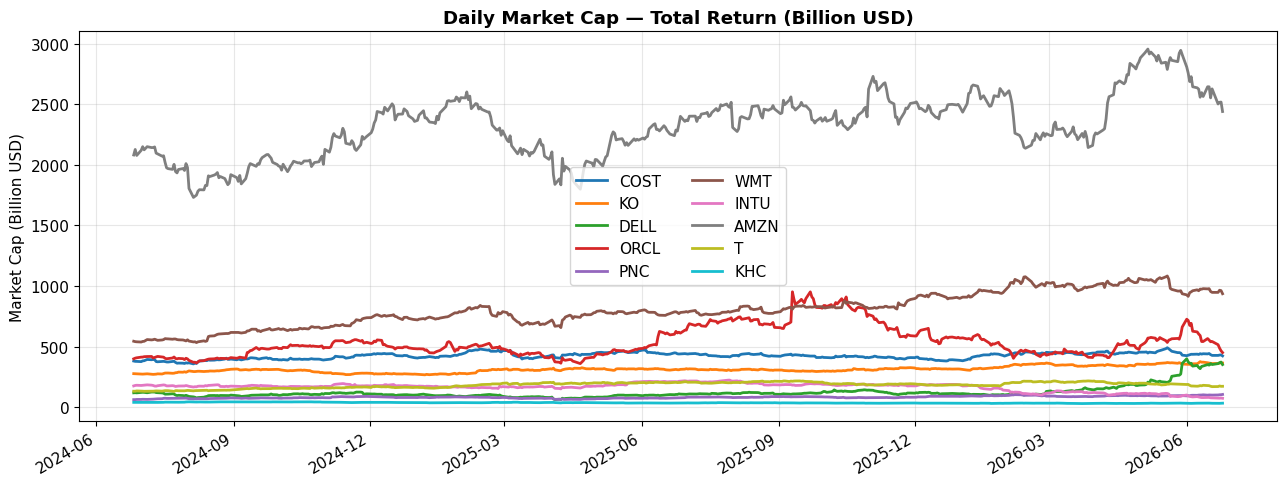

In [15]:
if market_cap_data:
    fig, ax = plt.subplots(figsize=(13, 5))
    for (t, df), color in zip(market_cap_data.items(), COLORS):
        ax.plot(df.index, df['MarketCap_TR']/1e9, label=t, color=color, lw=2)
    ax.set_title('Daily Market Cap — Total Return (Billion USD)', fontweight='bold')
    ax.set_ylabel('Market Cap (Billion USD)')
    ax.legend(ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/market_cap_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 5 · Download Risk-Free Rates: DGS1 + SOFR (FRED)

- **DGS1** — 1-Year Treasury Constant Maturity Rate (primary KMV risk-free rate)
- **SOFR** — Secured Overnight Financing Rate
- **DGS10** — 10-Year Treasury (reference)

Source: https://fred.stlouisfed.org — public CSV endpoint, no API key needed.

In [16]:
FRED_BASE = 'https://fred.stlouisfed.org/graph/fredgraph.csv'

def download_fred(series_id: str, years: int = 2) -> pd.Series:
    """Download a FRED series as a decimal-valued pd.Series."""
    start = (datetime.today() - timedelta(days=years*365+30)).strftime('%Y-%m-%d')
    url   = f'{FRED_BASE}?id={series_id}&observation_start={start}'
    resp  = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text), index_col=0, parse_dates=True)
    df.index.name = 'Date'
    s = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna()
    s.name = series_id
    return s / 100.0   # % → decimal


rf_series = {}
FRED_IDS  = {
    'DGS1' : '1-Year Treasury CMT (KMV risk-free rate)',
    'SOFR' : 'Secured Overnight Financing Rate',
    'DGS10': '10-Year Treasury CMT (reference)',
}

print('Downloading risk-free rates from FRED ...\n')
for sid, desc in FRED_IDS.items():
    print(f'  [{sid}]', end=' ')
    try:
        s = download_fred(sid, HISTORY_YEARS)
        rf_series[sid] = s
        print(f'✅  {len(s)} obs  | Latest ({s.index[-1].date()}): {s.iloc[-1]:.3%}  — {desc}')
    except Exception as e:
        print(f'❌  {e}')

# ── Merge into daily DataFrame ────────────────────────────────────────────────
if rf_series:
    rf_df = pd.DataFrame(rf_series).ffill()
    rf_df['RiskFreeRate'] = rf_df.get('DGS1', pd.Series(dtype=float))
    rf_df.to_csv(f'{OUTPUT_DIR}/risk_free_rates.csv')
    print(f'\nRisk-free rate table: {len(rf_df)} rows, saved ✅')
    display(rf_df.tail(5).style.format('{:.4%}'))
else:
    print('\n⚠️  No FRED data downloaded')


  [DGS1] ✅  16104 obs  | Latest (2026-06-24): 3.990%  — 1-Year Treasury CMT (KMV risk-free rate)
  [SOFR] ✅  2054 obs  | Latest (2026-06-24): 3.620%  — Secured Overnight Financing Rate
  [DGS10] ✅  16104 obs  | Latest (2026-06-24): 4.410%  — 10-Year Treasury CMT (reference)

Risk-free rate table: 16104 rows, saved ✅


,DGS1,SOFR,DGS10,RiskFreeRate
Date,,,,
2026-06-17 00:00:00,3.9800%,3.6300%,4.4900%,3.9800%
2026-06-18 00:00:00,4.0000%,3.6200%,4.4600%,4.0000%
2026-06-22 00:00:00,4.0400%,3.6100%,4.5100%,4.0400%
2026-06-23 00:00:00,4.0100%,3.6200%,4.5000%,4.0100%
2026-06-24 00:00:00,3.9900%,3.6200%,4.4100%,3.9900%


### 5.1 · Plot: Risk-Free Rates

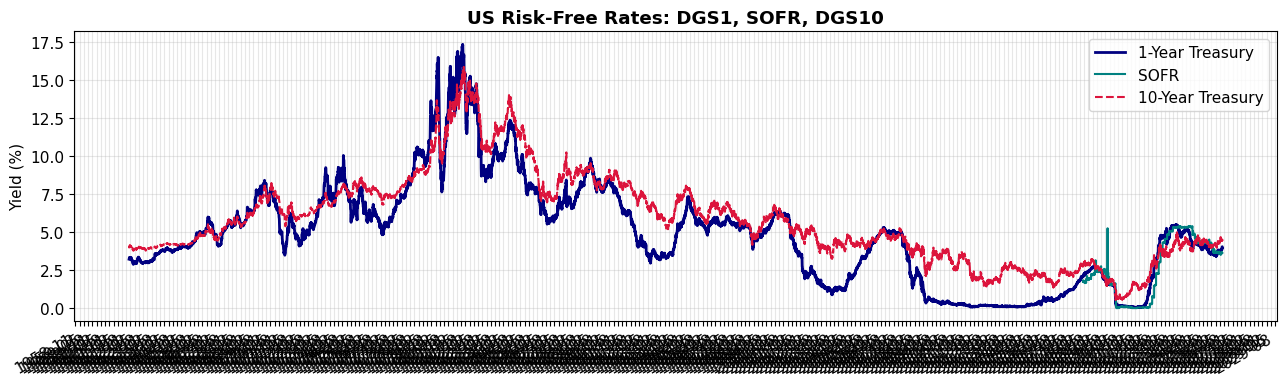

In [17]:
if 'rf_df' in dir() and not rf_df.empty:
    fig, ax = plt.subplots(figsize=(13, 4))
    styles = {'DGS1':('1-Year Treasury','navy',2.0,'-'),
              'SOFR':('SOFR','teal',1.5,'-'),
              'DGS10':('10-Year Treasury','crimson',1.5,'--')}
    for col,(label,color,lw,ls) in styles.items():
        if col in rf_df:
            ax.plot(rf_df.index, rf_df[col]*100, label=label, color=color, lw=lw, linestyle=ls)
    ax.set_title('US Risk-Free Rates: DGS1, SOFR, DGS10', fontweight='bold')
    ax.set_ylabel('Yield (%)')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/risk_free_rate_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 6 · Build Master Dataset (Daily)

Merges price, market cap, and risk-free rates into one daily table per ticker.  
Balance sheet / financials are annual snapshots attached separately (see Step 3 output).

| Column | Description |
|--------|-------------|
| `Close` | Split-adjusted close |
| `AdjClose_TR` | Total-return adjusted close |
| `Dividends` | Per-share dividend on ex-date |
| `CumDividends` | Cumulative dividends since period start |
| `Shares` | Shares outstanding (latest) |
| `MarketCap_TR` | $E_t$ = AdjClose_TR × Shares |
| `RiskFreeRate` | DGS1 (decimal), forward-filled |
| `SOFR` | SOFR (decimal), forward-filled |

In [18]:
master_data = {}

print('Building master datasets ...\n')
for t in TICKERS:
    if t not in market_cap_data:
        print(f'  [{t}] ⚠️  No market cap data — skipping')
        continue
    try:
        master = market_cap_data[t].copy()
        master['RiskFreeRate'] = rf_df['RiskFreeRate'].reindex(master.index, method='ffill')
        if 'SOFR' in rf_df.columns:
            master['SOFR'] = rf_df['SOFR'].reindex(master.index, method='ffill')

        master_data[t] = master
        master.to_csv(f'{OUTPUT_DIR}/{t}/{t}_master.csv')
        print(f'  [{t}] ✅  {len(master)} rows  '
              f'| Latest E: ${master["MarketCap_TR"].iloc[-1]/1e9:.2f}B  '
              f'| r: {master["RiskFreeRate"].iloc[-1]:.3%}')
    except Exception as e:
        print(f'  [{t}] ❌  {e}')

print('\nMaster datasets saved ✅')

Building master datasets ...

  [COST] ✅  501 rows  | Latest E: $422.36B  | r: 3.990%
  [KO] ✅  501 rows  | Latest E: $363.52B  | r: 3.990%
  [DELL] ✅  501 rows  | Latest E: $350.73B  | r: 3.990%
  [ORCL] ✅  501 rows  | Latest E: $449.81B  | r: 3.990%
  [PNC] ✅  501 rows  | Latest E: $103.80B  | r: 3.990%
  [WMT] ✅  501 rows  | Latest E: $936.12B  | r: 3.990%
  [INTU] ✅  501 rows  | Latest E: $72.14B  | r: 3.990%
  [AMZN] ✅  501 rows  | Latest E: $2441.97B  | r: 3.990%
  [T] ✅  501 rows  | Latest E: $171.23B  | r: 3.990%
  [KHC] ✅  501 rows  | Latest E: $31.62B  | r: 3.990%

Master datasets saved ✅


### 6.1 · Plot: Market Equity vs KMV Debt D (Annual snapshot)

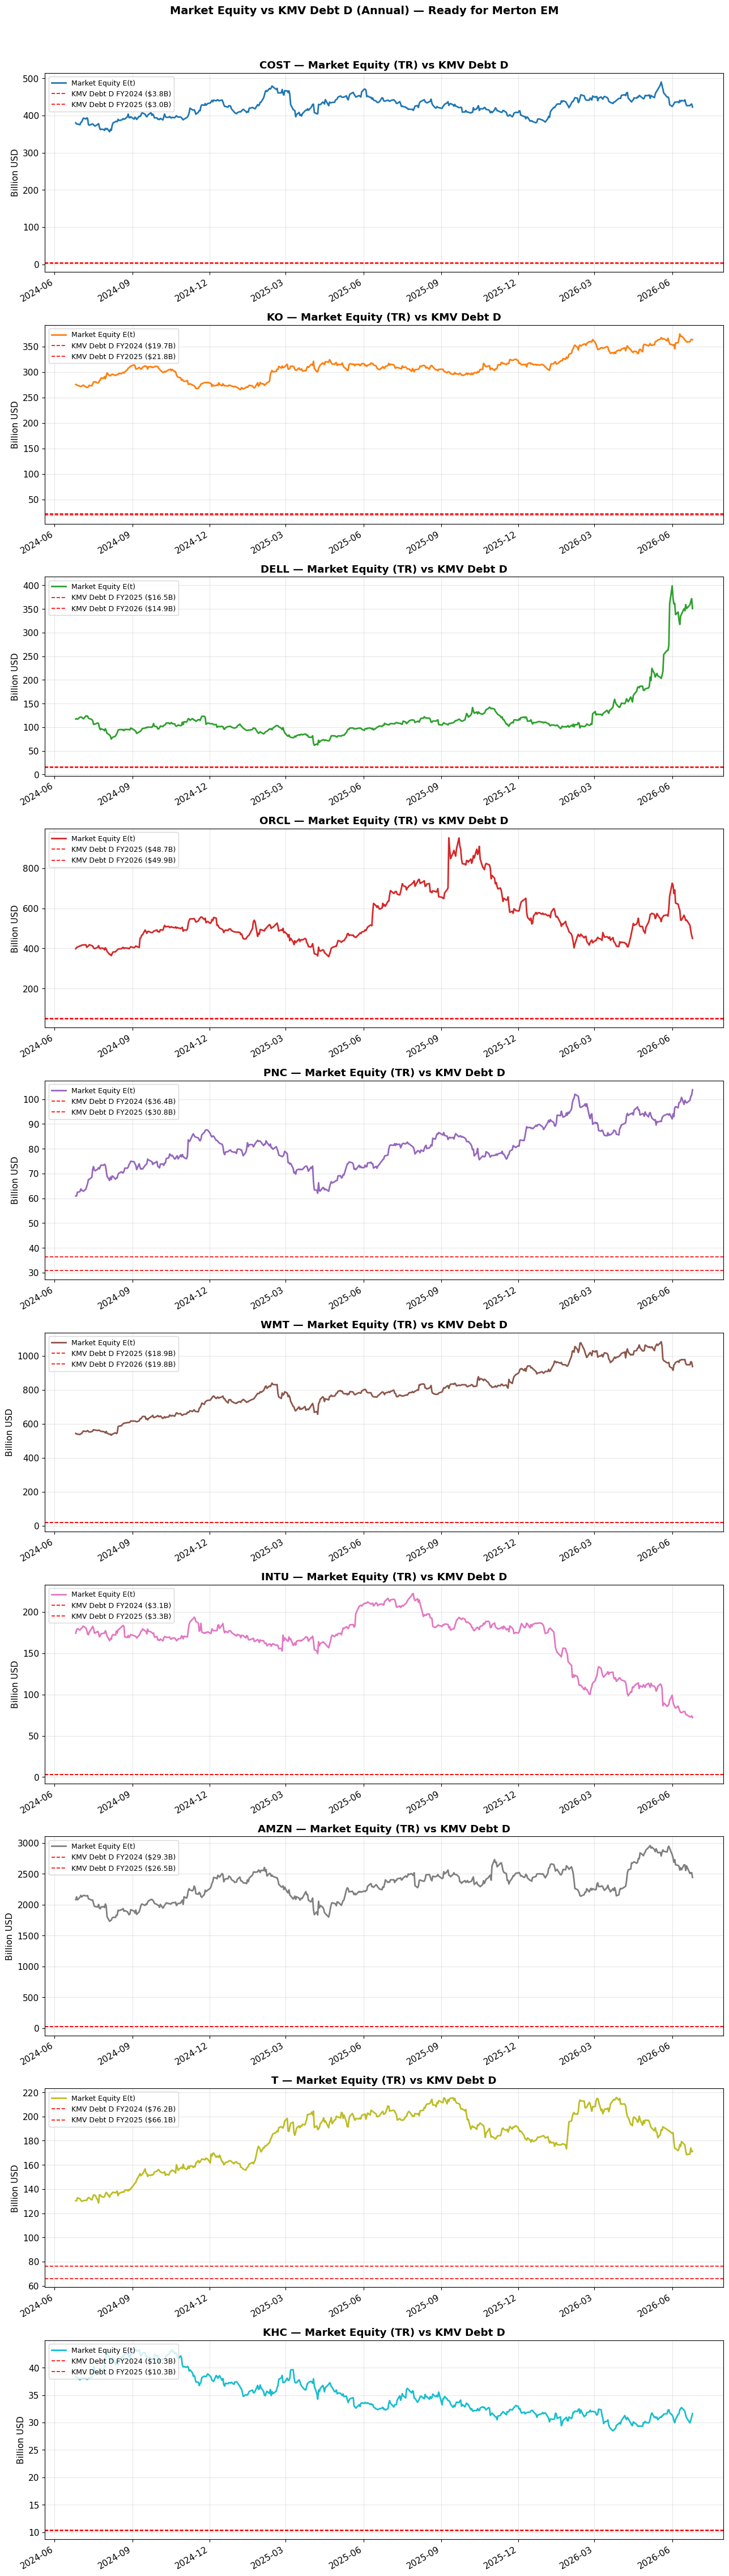

In [19]:
if not master_data:
    print('⚠️  master_data is empty — check Steps 2–5 ran successfully')
else:
    fig, axes = plt.subplots(len(master_data), 1,
                             figsize=(13, 4.5 * len(master_data)), sharex=False)
    if len(master_data) == 1: axes = [axes]

    for ax, (t, master), color in zip(axes, master_data.items(), COLORS):
        E = master['MarketCap_TR'] / 1e9
        ax.plot(master.index, E, label='Market Equity E(t)', color=color, lw=2)

        # Overlay latest KMV_Debt_D as horizontal reference lines
        if t in sec_financials and not sec_financials[t].empty:
            for _, row in sec_financials[t].iterrows():
                D = row['KMV_Debt_D'] / 1e3   # $mm → $B
                fy = int(row['fiscalYear'])
                ax.axhline(D, color='red', lw=1.2, linestyle='--',
                           label=f'KMV Debt D FY{fy} (${D:.1f}B)')

        ax.set_title(f'{t} — Market Equity (TR) vs KMV Debt D', fontweight='bold')
        ax.set_ylabel('Billion USD')
        ax.legend(loc='upper left', fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.suptitle('Market Equity vs KMV Debt D (Annual) — Ready for Merton EM',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/equity_vs_debt_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 7 · Export to Excel (one workbook per company)

Sheets per workbook:
- `PriceHistory` — daily OHLCV + dividend adjustment
- `MarketCap` — daily market cap
- `Financials` — annual balance sheet (2 fiscal years, from SEC)
- `RiskFreeRates` — daily DGS1, SOFR, DGS10
- `MasterDataset` — daily merged table
- `CompanyInfo` — metadata snapshot

In [20]:
print('Exporting to Excel ...\n')

for t in TICKERS:
    if t not in master_data:
        continue
    path = f'{OUTPUT_DIR}/{t}/{t}_all_data.xlsx'
    try:
        with pd.ExcelWriter(path, engine='openpyxl') as writer:
            price_data[t].to_excel(writer, sheet_name='PriceHistory')
            if t in market_cap_data:
                market_cap_data[t].to_excel(writer, sheet_name='MarketCap')
            if t in sec_financials:
                sec_financials[t].to_excel(writer, sheet_name='Financials', index=False)
            rf_df.to_excel(writer, sheet_name='RiskFreeRates')
            master_data[t].to_excel(writer, sheet_name='MasterDataset')
            pd.DataFrame([company_info[t]], index=[t]).T.to_excel(
                writer, sheet_name='CompanyInfo', header=False)
        print(f'  [{t}] ✅  {path}')
    except Exception as e:
        print(f'  [{t}] ❌  {e}')

print('\nAll Excel files saved ✅')

Exporting to Excel ...

  [COST] ✅  ./data/COST/COST_all_data.xlsx
  [KO] ✅  ./data/KO/KO_all_data.xlsx
  [DELL] ✅  ./data/DELL/DELL_all_data.xlsx
  [ORCL] ✅  ./data/ORCL/ORCL_all_data.xlsx
  [PNC] ✅  ./data/PNC/PNC_all_data.xlsx
  [WMT] ✅  ./data/WMT/WMT_all_data.xlsx
  [INTU] ✅  ./data/INTU/INTU_all_data.xlsx
  [AMZN] ✅  ./data/AMZN/AMZN_all_data.xlsx
  [T] ✅  ./data/T/T_all_data.xlsx
  [KHC] ✅  ./data/KHC/KHC_all_data.xlsx

All Excel files saved ✅


---
## Step 8 · Data Quality Check

In [21]:
print('\n' + '='*75)
print('  DATA QUALITY REPORT')
print('='*75)

for t in TICKERS:
    print(f'\n  ── {t} ──────────────────────────────────────────────────')

    # Price data
    if t in price_data:
        df = price_data[t]
        print(f'  Price rows          : {len(df)}'
              f'  | Missing Close: {df["Close"].isna().sum()}')
        print(f'  Dividend events     : {(df["Dividends"]>0).sum()}'
              f'  | Total divs paid: ${df["Dividends"].sum():.4f}/share')
        print(f'  AdjClose_TR latest  : ${df["AdjClose_TR"].iloc[-1]:,.2f}')
    else:
        print('  ⚠️  No price data')

    # Market cap
    if t in market_cap_data:
        mc = market_cap_data[t]['MarketCap_TR'].iloc[-1]
        print(f'  Market Cap (TR)     : ${mc/1e9:.2f}B')

    # SEC financials
    if t in sec_financials:
        df_fin = sec_financials[t]
        for _, row in df_fin.iterrows():
            fy = int(row['fiscalYear'])
            st  = row.get('currentDebt', np.nan)
            lt  = row.get('longTermDebt', np.nan)
            D   = row.get('KMV_Debt_D', np.nan)
            tl  = row.get('totalLiabilities', np.nan)
            dps = row.get('dividendPerShare', np.nan)
            print(f'  FY{fy}: ST Debt ${st:,.0f}mm  LT Debt ${lt:,.0f}mm  '
                  f'KMV D ${D:,.0f}mm  TotalLiab ${tl:,.0f}mm  DPS ${dps:.4f}')
    else:
        print('  ⚠️  No SEC financial data')

    # Risk-free rates
    if t in master_data:
        last = master_data[t].iloc[-1]
        print(f'  DGS1 (latest)       : {last["RiskFreeRate"]:.4%}')
        if 'SOFR' in last:
            print(f'  SOFR (latest)       : {last["SOFR"]:.4%}')

print('\n' + '='*75)


  DATA QUALITY REPORT

  ── COST ──────────────────────────────────────────────────
  Price rows          : 501  | Missing Close: 0
  Dividend events     : 8  | Total divs paid: $10.1500/share
  AdjClose_TR latest  : $952.39
  Market Cap (TR)     : $422.36B
  FY2024: ST Debt $1,081mm  LT Debt $5,377mm  KMV D $3,770mm  TotalLiab $43,936mm  DPS $3.8400
  FY2025: ST Debt $103mm  LT Debt $5,794mm  KMV D $3,000mm  TotalLiab $46,209mm  DPS $19.3600
  DGS1 (latest)       : 3.9900%
  SOFR (latest)       : 3.6200%

  ── KO ──────────────────────────────────────────────────
  Price rows          : 501  | Missing Close: 0
  Dividend events     : 8  | Total divs paid: $4.0700/share
  AdjClose_TR latest  : $84.49
  Market Cap (TR)     : $363.52B
  FY2024: ST Debt $1,960mm  LT Debt $35,547mm  KMV D $19,734mm  TotalLiab $71,762mm  DPS $1.7600
  FY2025: ST Debt $648mm  LT Debt $42,375mm  KMV D $21,836mm  TotalLiab $75,693mm  DPS $1.8400
  DGS1 (latest)       : 3.9900%
  SOFR (latest)       : 3.6200%


---
## Step 9 · Final File Summary

In [22]:
print('\n' + '='*75)
print('  OUTPUT FILE SUMMARY')
print('='*75)

for t in TICKERS:
    folder = f'{OUTPUT_DIR}/{t}'
    if not os.path.exists(folder): continue
    files = sorted(os.listdir(folder))
    print(f'\n  📁 {folder}/')
    for f in files:
        size = os.path.getsize(os.path.join(folder, f))
        print(f'     📄 {f:<52} {size/1024:>7.1f} KB')

print(f'\n  📁 {OUTPUT_DIR}/')
for f in ['risk_free_rates.csv','price_history_chart.png','normalised_performance.png',
          'market_cap_chart.png','risk_free_rate_chart.png','equity_vs_debt_chart.png']:
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.exists(fpath):
        print(f'     📄 {f:<52} {os.path.getsize(fpath)/1024:>7.1f} KB')


  OUTPUT FILE SUMMARY

  📁 ./data/COST/
     📄 COST_all_data.xlsx                                     480.8 KB
     📄 COST_financials.csv                                      1.2 KB
     📄 COST_market_cap.csv                                     42.2 KB
     📄 COST_master.csv                                         52.2 KB
     📄 COST_price_history.csv                                  45.2 KB

  📁 ./data/KO/
     📄 KO_all_data.xlsx                                       478.6 KB
     📄 KO_financials.csv                                        1.3 KB
     📄 KO_market_cap.csv                                       39.1 KB
     📄 KO_master.csv                                           49.1 KB
     📄 KO_price_history.csv                                    39.9 KB

  📁 ./data/DELL/
     📄 DELL_all_data.xlsx                                     481.9 KB
     📄 DELL_financials.csv                                      1.2 KB
     📄 DELL_market_cap.csv                                     42.0 KB
  